<div align="center">

# 🔍 eda-toolkit — Quickstart

### *Stop rewriting the same first ten cells.*

**A walkthrough of every module in the library, on a real dataset.**

<img src="https://img.shields.io/badge/Python-3.8%2B-3776AB?style=for-the-badge&logo=python&logoColor=white" />
<img src="https://img.shields.io/badge/pandas-150458?style=for-the-badge&logo=pandas&logoColor=white" />
<img src="https://img.shields.io/badge/Plotly-3F4F75?style=for-the-badge&logo=plotly&logoColor=white" />
<img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white" />

</div>

---

## What this notebook covers

Opening an unfamiliar dataset means writing the same cells every single time — check
what's missing, make a table readable, plot correlations, hunt outliers, find
duplicate records. `eda-toolkit` collapses each of those into a one-line call.

This notebook runs through all five modules in the order you'd actually use them:

| Step | Module | What we do |
|:--:|---|---|
| **1** | `diagnostics` | Survey the dataset — missing values, percentages, dtypes |
| **2** | `styling` | Render readable, highlighted DataFrame previews |
| **3** | `extractors` | Pull numeric values out of messy text columns |
| **4** | `visualization` | Correlations, scatter + trendlines, outlier box plots |
| **5** | `name_matching` | Catch exact and near-duplicate records |

### The dataset

**Global AI Tools Landscape (2020–2026)** — 3,010 AI tools across 10 categories, with
pricing, open-source status, GitHub stars, company, and estimated monthly users.

> ⚠️ **This data is synthetic.** Per its author it does not reflect real-world
> figures — real tools were used only to model realistic distributions. Nothing
> plotted below should be cited as a real statistic. Source and licence:
> [`data/README.md`](data/README.md).

### Setup

From the repository root:

```bash
pip install -e ".[all]"
```

---

In [1]:
import sys
from pathlib import Path

import pandas as pd
import plotly.io as pio

# Make the library importable when running from a clone without `pip install -e .`
sys.path.insert(0, str(Path.cwd().parent))

# Render Plotly figures as static images. GitHub strips JavaScript from committed
# notebooks, so interactive charts show as blank space. Comment this out for
# fully interactive charts when running locally.
pio.renderers.default = "png"

ai_tools = pd.read_csv(Path("data") / "global_ai_tools_dataset_final.csv")

print(f"{ai_tools.shape[0]:,} rows x {ai_tools.shape[1]} columns")
ai_tools.head()

3,010 rows x 9 columns


,tool_name,category,release_year,pricing,open_source,github_stars,company,monthly_users,tags
0,ChatGPT,LLM,2022,Freemium,No,180000,OpenAI,180000000,"chatbot,text,assistant"
1,Midjourney,Image Generation,2022,Paid,No,0,Independent,20000000,"image,design,art"
2,Claude,LLM,2023,Freemium,No,0,Anthropic,15000000,"chatbot,text,assistant"
3,Gemini,LLM,2024,Freemium,No,0,Google,120000000,"chatbot,text,search"
4,Stable Diffusion,Image Generation,2022,Free,Yes,150000,Stability AI,10000000,"image,generation,design"


---

## 1️⃣ `diagnostics` — what am I working with?

The first question on any new dataset is *where are the holes?*  `missing_values()`
answers it in one call: count and percentage of nulls per column, alongside each
column's dtype and the total row count.

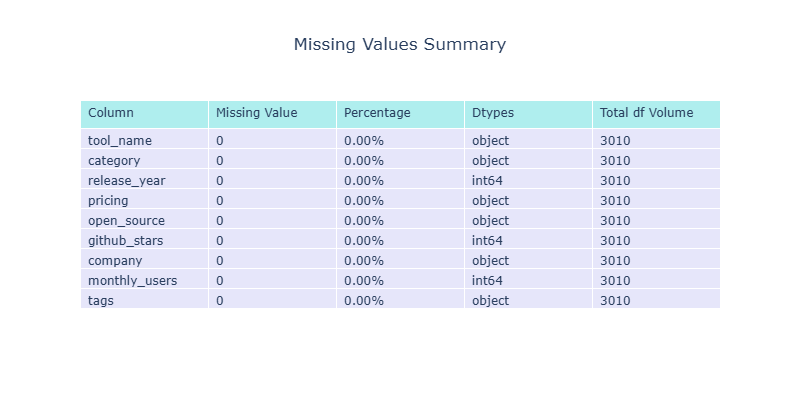

In [2]:
from eda_toolkit.diagnostics import missing_values

missing_values(ai_tools)

**Result: zero missing values across all nine columns.**

That's a finding, not a non-event — it tells us no imputation strategy is needed and
we can go straight to analysis. It also confirms the dtypes are what we expect:
three integer columns (`release_year`, `github_stars`, `monthly_users`) and six text
columns.

We'll come back to this function in step 3, once we've *created* some missing data.

---

## 2️⃣ `styling` — make the table readable

`df.head()` gives you an unformatted wall of numbers. The `styling` module wraps
pandas' Styler so a preview is actually scannable.

In [3]:
from eda_toolkit.styling import make_pretty, view_df

make_pretty(ai_tools, nr_rows=8, set_caption="Global AI Tools — sample rows")

,tool_name,category,release_year,pricing,open_source,github_stars,company,monthly_users,tags
0,ChatGPT,LLM,2022,Freemium,No,180000,OpenAI,180000000,"chatbot,text,assistant"
1,Midjourney,Image Generation,2022,Paid,No,0,Independent,20000000,"image,design,art"
2,Claude,LLM,2023,Freemium,No,0,Anthropic,15000000,"chatbot,text,assistant"
3,Gemini,LLM,2024,Freemium,No,0,Google,120000000,"chatbot,text,search"
4,Stable Diffusion,Image Generation,2022,Free,Yes,150000,Stability AI,10000000,"image,generation,design"
5,Runway,Video AI,2023,Freemium,No,5000,Runway,8000000,"video,editing,ai"
6,Perplexity,Research AI,2022,Freemium,No,12000,Perplexity,25000000,"search,research,assistant"
7,GitHub Copilot,Coding Assistant,2021,Paid,No,0,Microsoft,30000000,"coding,developer,assistant"


`view_df()` sorts on a column and applies a highlight. The `focus` argument picks the
treatment: `"max"`, `"min"`, `"null"`, `"heatmap"`, or `"bar"`.

In [4]:
# The most-used tools in the dataset, with the peak value highlighted
view_df(ai_tools, column="monthly_users", focus="max", nr_rws=8)

,tool_name,category,release_year,pricing,open_source,github_stars,company,monthly_users,tags
0,ChatGPT,LLM,2022,Freemium,No,180000,OpenAI,180000000,"chatbot,text,assistant"
3,Gemini,LLM,2024,Freemium,No,0,Google,120000000,"chatbot,text,search"
1192,AITool_1183,Design AI,2025,Free,Yes,86583,Independent,49997223,"productivity,chatbot,developer"
2137,AITool_2128,Speech AI,2026,Freemium,Yes,186130,Startup,49975189,"marketing,voice,automation"
2890,AITool_2881,Image Generation,2020,Enterprise,Yes,153545,Meta,49966016,"video,assistant,developer"
265,AITool_256,Marketing AI,2022,Free,No,46576,Anthropic,49962656,"voice,assistant,image"
2374,AITool_2365,Coding Assistant,2025,Freemium,Yes,136760,Microsoft,49947066,"text,automation,chatbot"
1991,AITool_1982,Music AI,2022,Paid,No,166716,Independent,49943728,"design,research,marketing"


In [5]:
# Same rows, shaded as a gradient instead — easier for comparing magnitudes
view_df(ai_tools, column="github_stars", focus="heatmap", nr_rws=8)

,tool_name,category,release_year,pricing,open_source,github_stars,company,monthly_users,tags
1337,AITool_1328,LLM,2024,Enterprise,Yes,199874,Meta,22509410,"research,text,developer"
902,AITool_893,Video AI,2023,Enterprise,No,199828,Google,19571649,"video,assistant,automation"
1577,AITool_1568,Music AI,2026,Free,No,199648,Independent,25968295,"marketing,productivity,video"
229,AITool_220,LLM,2020,Free,Yes,199571,Adobe,5038787,"assistant,voice,video"
456,AITool_447,Marketing AI,2021,Free,Yes,199508,Google,36450760,"image,automation,video"
2050,AITool_2041,Coding Assistant,2021,Paid,Yes,199452,Google,17892810,"automation,research,chatbot"
779,AITool_770,Music AI,2025,Free,Yes,199433,Meta,17382008,"image,design,chatbot"
2432,AITool_2423,Coding Assistant,2023,Freemium,Yes,199427,Meta,41208693,"assistant,design,developer"


---

## 3️⃣ `extractors` — pull numbers out of text

Most `tool_name` values in this dataset follow a synthetic `AITool_1234` pattern,
with the well-known real tools (ChatGPT, Midjourney, Claude…) mixed in under their
actual names.

`extract_nr()` strips everything non-numeric and returns an integer — or `NaN` when
there's no digit to find. That gives us a clean ID column *and* a way to separate
generated entries from real ones.

In [6]:
from eda_toolkit.extractors import extract_nr

ai_tools["tool_id"] = ai_tools["tool_name"].apply(extract_nr)

# Real tools have no digits in their name, so they come back as NaN
ai_tools[["tool_name", "tool_id"]].head(8)

,tool_name,tool_id
0,ChatGPT,NaN
1,Midjourney,NaN
2,Claude,NaN
3,Gemini,NaN
4,Stable Diffusion,NaN
5,Runway,NaN
6,Perplexity,NaN
7,GitHub Copilot,NaN


Now re-run the diagnostic. Our new column has genuine gaps in it, so this time
`missing_values()` has something to report — exactly what it looks like on a
real-world dataset that arrives incomplete.

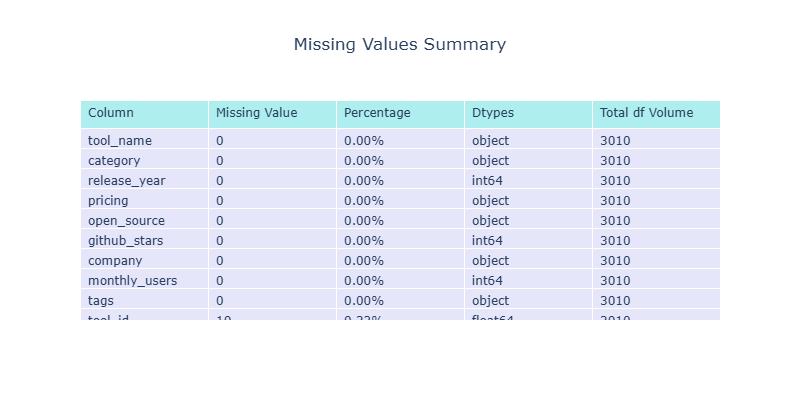

In [7]:
missing_values(ai_tools)

---

## 4️⃣ `visualization` — explore the numbers

Three charts, three one-line calls. All are Plotly, so locally they're fully
interactive — hover, zoom, and pan.

Start with how the numeric columns relate to each other.

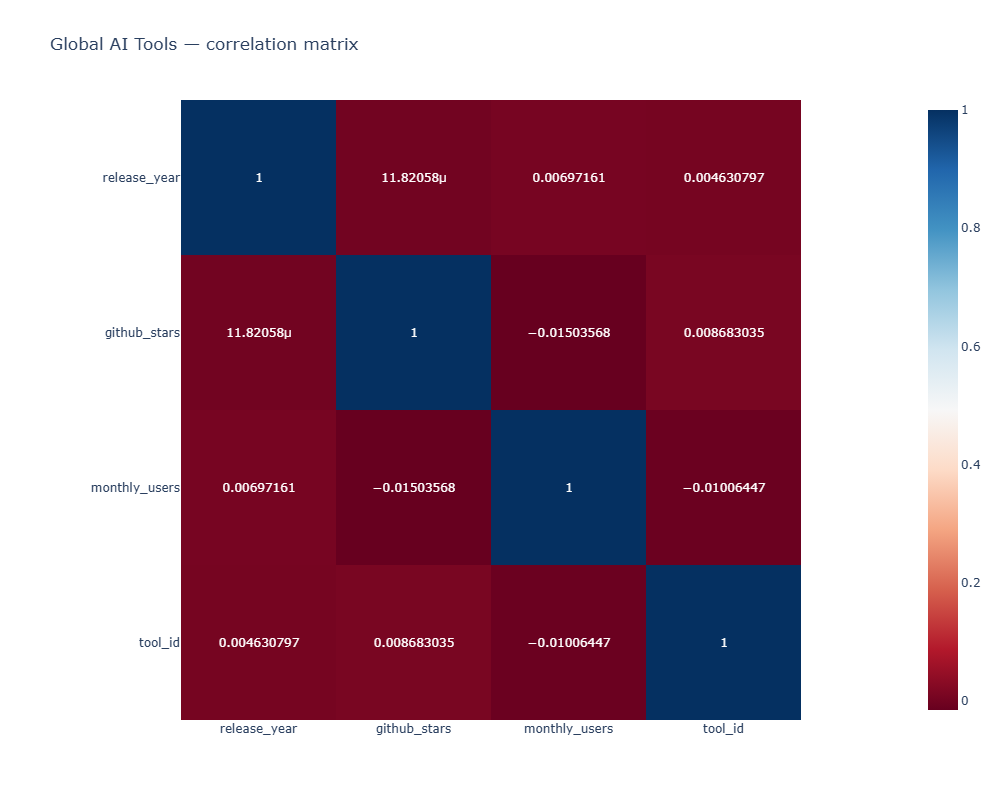

In [8]:
from eda_toolkit.visualization import corr_plot, scatter_plot, outliers_plot

corr_plot(ai_tools, title="Global AI Tools — correlation matrix")

`scatter_plot()` plots one or more features against a target and fits an OLS
trendline through each.

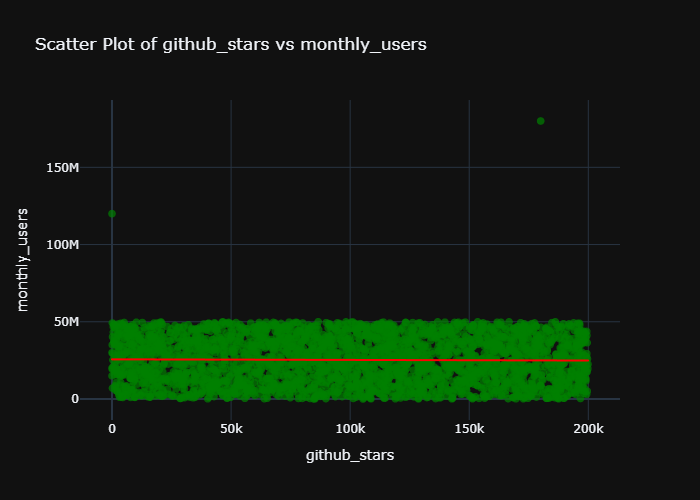

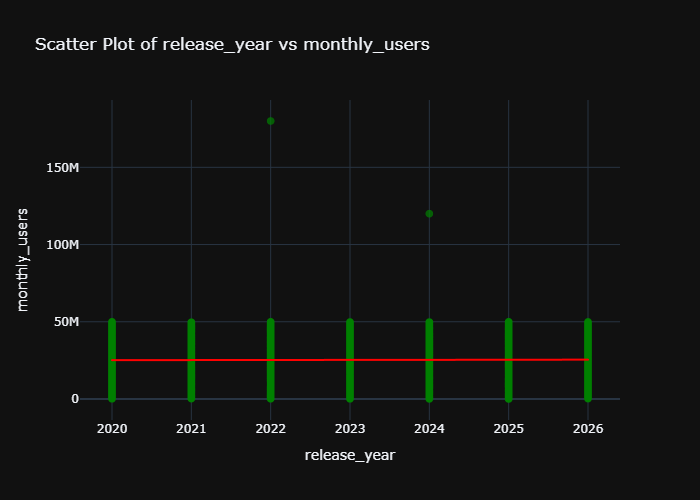

In [9]:
scatter_plot(
    ai_tools,
    target="monthly_users",
    columns=["github_stars", "release_year"],
)

`outliers_plot()` draws a box plot per numeric column with a slider to step between
features — useful when you want to eyeball spread and extremes without writing a
loop.

> **Note:** the slider is interactive and needs JavaScript. In the static render
> below you'll see only the first feature. Run this notebook locally (with the `png`
> renderer commented out) to page through the rest.

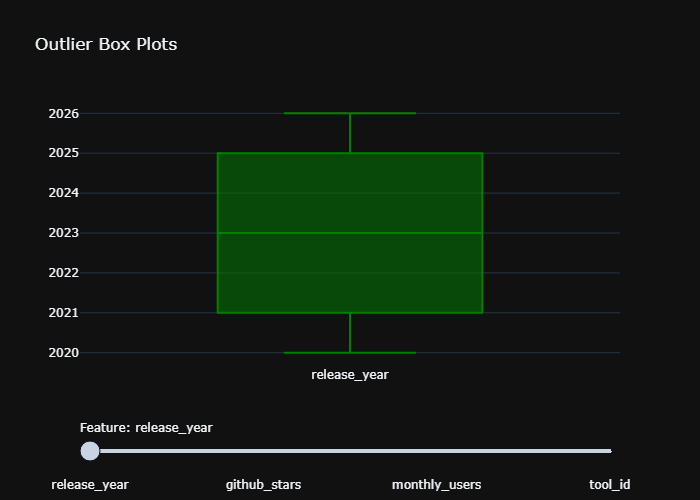

In [10]:
outliers_plot(ai_tools)

---

## 5️⃣ `name_matching` — find duplicate records

This module is built for **person-name deduplication** — its defaults expect
`FirstName` and `Surname` columns. Both column names are parameters, though, so it
works on any pair of categorical columns.

This dataset has no person names, so we'll point it at `company` + `category` to
answer a different question: *which companies ship multiple tools in the same
category?*

In [11]:
from eda_toolkit.name_matching import (
    find_exact_name_duplicates,
    find_fuzzy_name_duplicates,
)

overlaps = find_exact_name_duplicates(
    ai_tools,
    first_name_col="company",
    surname_col="category",
    min_count=2,
)

print(f"{len(overlaps)} company/category pairs with more than one tool")
overlaps.head(10)

90 company/category pairs with more than one tool


,company,category,Count
43,Independent,Design AI,52
3,AWS,LLM,42
87,Startup,Image Generation,42
88,Startup,LLM,42
26,Anthropic,Productivity AI,42
85,Startup,Coding Assistant,42
45,Independent,LLM,41
70,Microsoft,Speech AI,40
52,Meta,Coding Assistant,40
18,Adobe,Speech AI,40


The fuzzy matcher catches *near*-duplicates — names that differ by typos, casing, or
word order — using a token-sort ratio.

> ⚠️ **It compares every pair of rows, so runtime is O(n²).** On all 3,010 rows
> that's ~4.5 million comparisons. Always pre-filter or sample first.

In [12]:
sample = ai_tools.sample(300, random_state=42)

near_dupes = find_fuzzy_name_duplicates(
    sample,
    first_name_col="tool_name",
    surname_col="company",
    score_cutoff=95,
)

print(f"{len(near_dupes)} near-duplicate pairs found in {len(sample)} sampled rows")
print()
for a_tool, a_co, b_tool, b_co, score in near_dupes[:8]:
    print(f"  {score:5.1f}   {a_tool:<14} ~  {b_tool:<14} ({a_co})")

63 near-duplicate pairs found in 300 sampled rows

   97.3   AITool_2861    ~  AITool_261     (Startup)
   95.5   AITool_798     ~  AITool_498     (Independent)
   95.7   AITool_1341    ~  AITool_1534    (Independent)
   95.7   AITool_1341    ~  AITool_1364    (Independent)
   95.7   AITool_1341    ~  AITool_1412    (Independent)
   95.7   AITool_1341    ~  AITool_1734    (Independent)
   95.2   AITool_1107    ~  AITool_1197    (Anthropic)
   97.6   AITool_2943    ~  AITool_943     (Anthropic)


Worth reading those results critically: `AITool_2861` and `AITool_261` score 97, but
they aren't really duplicates — they're distinct tools whose *synthetic* names happen
to share a digit sequence. That's a textbook fuzzy-matching false positive.

It's a useful reminder that `score_cutoff` is a dial, not a setting. On real
person-name data a cutoff of 90–95 catches genuine variants like *"Jon Smith"* vs
*"John Smith"*; on machine-generated identifiers like these it mostly finds noise.
Always eyeball the matches before trusting them.

---

## Recap

Five modules, one line each, covering the opening moves on any new dataset:

| Call | Answers |
|---|---|
| `missing_values(df)` | Where are the gaps, and what are the dtypes? |
| `make_pretty(df)` / `view_df(df, col, focus=...)` | What does the data actually look like? |
| `extract_nr(value)` | How do I get numbers out of text columns? |
| `corr_plot(df)` | What relates to what? |
| `scatter_plot(df, target, columns)` | How does X drive Y? |
| `outliers_plot(df)` | Where are the extremes? |
| `find_exact_name_duplicates(df)` / `find_fuzzy_name_duplicates(df)` | What's duplicated? |

Full documentation in the [project README](../README.md).

<div align="center">
<sub>Built with <a href="https://github.com/warsab/eda-toolkit">eda-toolkit</a> · MIT © Warrick Sabatta</sub>
</div>